<a href="https://colab.research.google.com/github/ewiw24/cvd-risk-classification-shap/blob/main/03_modeling_RF_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
✅ Data restored
   Train: 54,772 | Test: 13,693
🔍 Starting Random Forest GridSearchCV...
   120 total fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits

✅ Done in 19.2 min
   Best params : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
   Best CV F1  : 0.7335
📊 10-Fold CV on best RF model...

── RF CV Results (k=10) ──
   Accuracy    : 0.7341 ± 0.0053
   Precision   : 0.7357 ± 0.0054
   Recall      : 0.7341 ± 0.0053
   F1-Score    : 0.7335 ± 0.0053
   ROC-AUC     : 0.7990 ± 0.0057

── RF Test Set Performance ──
   Accuracy    : 0.7345
   Precision   : 0.7361
   Recall      : 0.7345
   F1-Score    : 0.7339
   ROC-AUC     : 0.8031

✅ rf_best saved
🔍 Starting XGBoost RandomizedSearchCV (n_iter=30)...
Fitting 10 folds for each of 30 candidates, totalling 300 fits

✅ Done in 8.7 min
   Best params : {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0

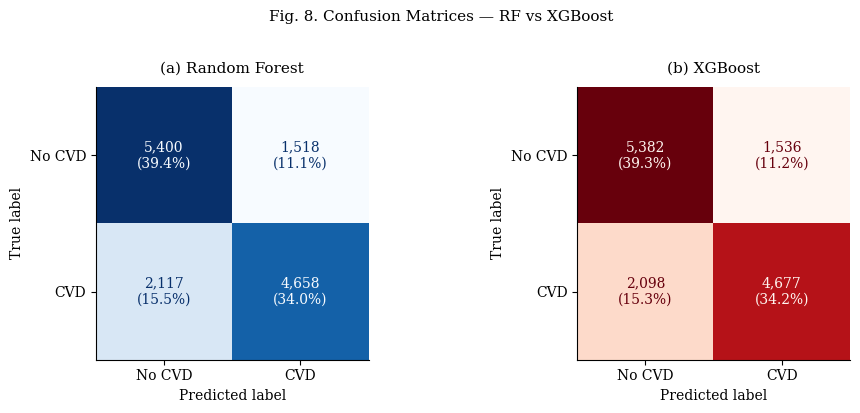

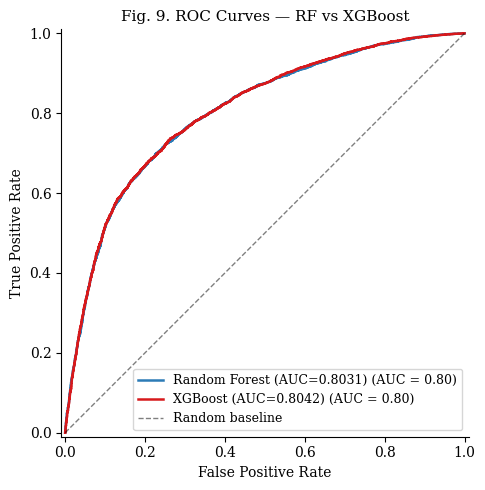

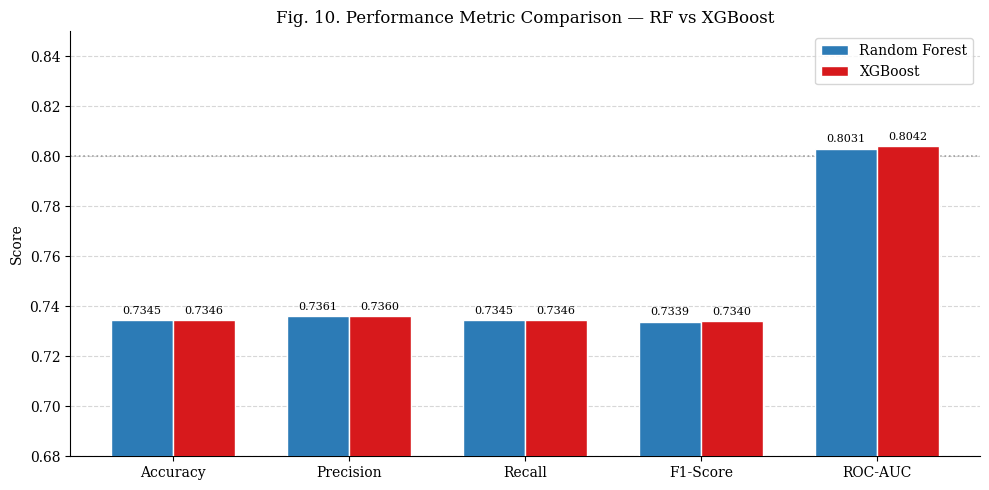

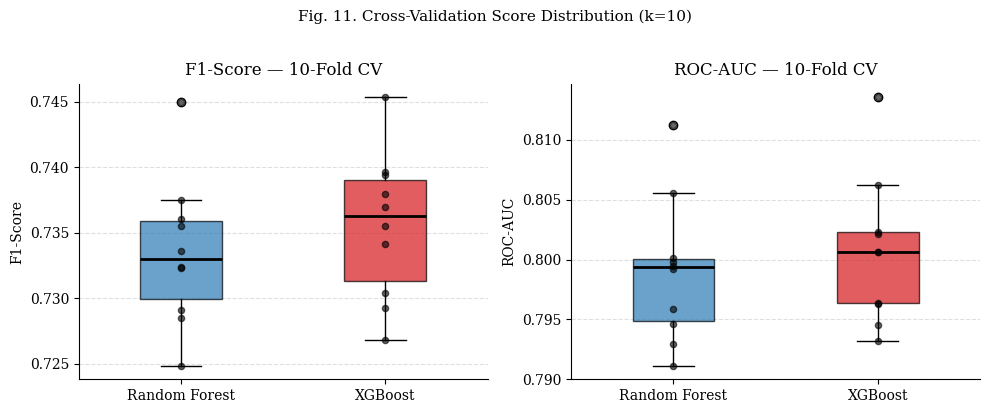


✅ Phase 3 complete
   RF  ROC-AUC: 0.8031
   XGB ROC-AUC: 0.8042
   XGBoost selected for SHAP (lower CV std: 0.0053 vs 0.0053)


In [1]:
# ── MARKDOWN ──────────────────────────────────────────────────
# # 03 — Model Training: Random Forest vs XGBoost
# **Goal:** Train and compare RF and XGBoost under identical
# experimental conditions using Stratified K-Fold CV (k=10).
# Hyperparameter tuning via GridSearchCV (RF) and
# RandomizedSearchCV (XGBoost).

# ── CELL 1: Setup & Restore ───────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pickle, joblib, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
    RandomizedSearchCV, cross_validate)
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier

SAVE_DIR = '/content/drive/MyDrive/CVD_Project'
PALETTE  = ['#2c7bb6', '#d7191c']

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

# Restore Phase 2
with open(f'{SAVE_DIR}/phase2_state.pkl', 'rb') as f:
    state = pickle.load(f)

X_train_scaled  = state['X_train_scaled']
X_test_scaled   = state['X_test_scaled']
y_train         = state['y_train']
y_test          = state['y_test']
FEATURES        = state['FEATURES']

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print("✅ Data restored")
print(f"   Train: {len(X_train_scaled):,} | Test: {len(X_test_scaled):,}")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 1. Random Forest — GridSearchCV

# ── CELL 2: RF Training ───────────────────────────────────────
rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 20, None],
    'max_features'     : ['sqrt', 'log2'],
}

print("🔍 Starting Random Forest GridSearchCV...")
print(f"   {len(rf_param_grid['n_estimators']) * len(rf_param_grid['max_depth']) * len(rf_param_grid['max_features']) * 10} total fits")

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    estimator  = rf_base,
    param_grid = rf_param_grid,
    scoring    = 'f1_weighted',
    cv         = cv_strategy,
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

t0 = time.time()
rf_grid.fit(X_train_scaled, y_train)
rf_time = time.time() - t0

rf_best = rf_grid.best_estimator_
print(f"\n✅ Done in {rf_time/60:.1f} min")
print(f"   Best params : {rf_grid.best_params_}")
print(f"   Best CV F1  : {rf_grid.best_score_:.4f}")

# ── CELL 3: RF Cross-Validation ───────────────────────────────
print("📊 10-Fold CV on best RF model...")
rf_cv = cross_validate(
    rf_best, X_train_scaled, y_train,
    cv      = cv_strategy,
    scoring = ['accuracy', 'precision_weighted',
               'recall_weighted', 'f1_weighted', 'roc_auc'],
    n_jobs  = -1
)

print("\n── RF CV Results (k=10) ──")
for metric, key in [('Accuracy',  'test_accuracy'),
                    ('Precision', 'test_precision_weighted'),
                    ('Recall',    'test_recall_weighted'),
                    ('F1-Score',  'test_f1_weighted'),
                    ('ROC-AUC',   'test_roc_auc')]:
    s = rf_cv[key]
    print(f"   {metric:12s}: {s.mean():.4f} ± {s.std():.4f}")

# ── CELL 4: RF Test Set Evaluation ───────────────────────────
y_pred_rf = rf_best.predict(X_test_scaled)
y_prob_rf = rf_best.predict_proba(X_test_scaled)[:, 1]

rf_metrics = {
    'Model'    : 'Random Forest',
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall'   : recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-Score' : f1_score(y_test, y_pred_rf, average='weighted'),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_rf),
}

print("\n── RF Test Set Performance ──")
for k, v in rf_metrics.items():
    if k != 'Model':
        print(f"   {k:12s}: {v:.4f}")

joblib.dump(rf_best, f'{SAVE_DIR}/rf_best.pkl')
print(f"\n✅ rf_best saved")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 2. XGBoost — RandomizedSearchCV

# ── CELL 5: XGBoost Training ──────────────────────────────────
xgb_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'max_depth'        : [3, 4, 5, 6, 8],
    'subsample'        : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 1.0],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [1, 1.5, 2],
    'min_child_weight' : [1, 3, 5],
}

print("🔍 Starting XGBoost RandomizedSearchCV (n_iter=30)...")

xgb_base = XGBClassifier(
    random_state = 42,
    n_jobs       = -1,
    eval_metric  = 'logloss',
    verbosity    = 0,
    device       = 'cuda',
)

xgb_search = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = xgb_param_dist,
    n_iter              = 30,
    scoring             = 'f1_weighted',
    cv                  = cv_strategy,
    n_jobs              = 1,
    verbose             = 1,
    random_state        = 42,
    refit               = True
)

t0 = time.time()
xgb_search.fit(X_train_scaled, y_train)
xgb_time = time.time() - t0

xgb_best = xgb_search.best_estimator_
print(f"\n✅ Done in {xgb_time/60:.1f} min")
print(f"   Best params : {xgb_search.best_params_}")
print(f"   Best CV F1  : {xgb_search.best_score_:.4f}")

# ── CELL 6: XGBoost CV & Test Evaluation ─────────────────────
print("📊 10-Fold CV on best XGBoost model...")
xgb_cv = cross_validate(
    xgb_best, X_train_scaled, y_train,
    cv      = cv_strategy,
    scoring = ['accuracy', 'precision_weighted',
               'recall_weighted', 'f1_weighted', 'roc_auc'],
    n_jobs  = 1
)

print("\n── XGBoost CV Results (k=10) ──")
for metric, key in [('Accuracy',  'test_accuracy'),
                    ('Precision', 'test_precision_weighted'),
                    ('Recall',    'test_recall_weighted'),
                    ('F1-Score',  'test_f1_weighted'),
                    ('ROC-AUC',   'test_roc_auc')]:
    s = xgb_cv[key]
    print(f"   {metric:12s}: {s.mean():.4f} ± {s.std():.4f}")

y_pred_xgb = xgb_best.predict(X_test_scaled)
y_prob_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

xgb_metrics = {
    'Model'    : 'XGBoost',
    'Accuracy' : accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, average='weighted'),
    'Recall'   : recall_score(y_test, y_pred_xgb, average='weighted'),
    'F1-Score' : f1_score(y_test, y_pred_xgb, average='weighted'),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_xgb),
}

print("\n── XGBoost Test Set Performance ──")
for k, v in xgb_metrics.items():
    if k != 'Model':
        print(f"   {k:12s}: {v:.4f}")

joblib.dump(xgb_best, f'{SAVE_DIR}/xgb_best.pkl')
print(f"\n✅ xgb_best saved")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 3. Comparison Figures

# ── CELL 7: Table II Print ────────────────────────────────────
print("=" * 62)
print("TABLE II. Model Performance Comparison")
print("=" * 62)
print(f"{'Metric':<14} {'RF Test':>10} {'XGB Test':>10} "
      f"{'RF CV':>10} {'XGB CV':>10}")
print("-" * 62)
for m in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']:
    rf_v   = rf_metrics[m]
    xgb_v  = xgb_metrics[m]
    rf_cv_k  = 'test_' + {'Accuracy':'accuracy',
                'Precision':'precision_weighted',
                'Recall':'recall_weighted',
                'F1-Score':'f1_weighted',
                'ROC-AUC':'roc_auc'}[m]
    print(f"{m:<14} {rf_v:>10.4f} {xgb_v:>10.4f} "
          f"{rf_cv[rf_cv_k].mean():>10.4f} "
          f"{xgb_cv[rf_cv_k].mean():>10.4f}")
print("=" * 62)

# ── CELL 8: Fig 8 — Confusion Matrices ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['(a) Random Forest', '(b) XGBoost'],
    ['Blues', 'Reds']
):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No CVD','CVD'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=11, pad=10)
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            ax.texts[i*2+j].set_text(
                f'{cm[i,j]:,}\n({cm[i,j]/total*100:.1f}%)')

plt.suptitle('Fig. 8. Confusion Matrices — RF vs XGBoost',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig8_confusion_matrices.png')
plt.show()

# ── CELL 9: Fig 9 — ROC Curves ───────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    name  = f"Random Forest (AUC={rf_metrics['ROC-AUC']:.4f})",
    ax=ax, color='#2c7bb6', linewidth=1.8)
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb,
    name  = f"XGBoost (AUC={xgb_metrics['ROC-AUC']:.4f})",
    ax=ax, color='#d7191c', linewidth=1.8)
ax.plot([0,1],[0,1],'k--',linewidth=1,alpha=0.5,label='Random baseline')
ax.set_title('Fig. 9. ROC Curves — RF vs XGBoost', fontsize=11)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig9_roc_curves.png')
plt.show()

# ── CELL 10: Fig 10 & 11 — Bar + CV Boxplot ──────────────────
metrics_show = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x, width = np.arange(len(metrics_show)), 0.35

# Fig 10 — Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, [rf_metrics[m]  for m in metrics_show],
            width, label='Random Forest', color='#2c7bb6',
            edgecolor='white', zorder=3)
b2 = ax.bar(x + width/2, [xgb_metrics[m] for m in metrics_show],
            width, label='XGBoost', color='#d7191c',
            edgecolor='white', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(metrics_show)
ax.set_ylim(0.68, 0.85)
ax.set_ylabel('Score')
ax.set_title('Fig. 10. Performance Metric Comparison — RF vs XGBoost')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.legend()
ax.bar_label(b1, fmt='%.4f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.4f', fontsize=8, padding=3)
ax.axhline(y=0.80, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig10_metric_comparison.png')
plt.show()

# Fig 11 — CV Boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (key, ylabel) in zip(axes, [
    ('test_f1_weighted', 'F1-Score'),
    ('test_roc_auc',     'ROC-AUC')
]):
    bp = ax.boxplot([rf_cv[key], xgb_cv[key]],
                    patch_artist=True,
                    labels=['Random Forest','XGBoost'], widths=0.4,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2c7bb6'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#d7191c'); bp['boxes'][1].set_alpha(0.7)
    for i, scores in enumerate([rf_cv[key], xgb_cv[key]], 1):
        ax.scatter([i]*len(scores), scores,
                   color='black', s=20, alpha=0.6, zorder=3)
    ax.set_title(f'{ylabel} — 10-Fold CV')
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Fig. 11. Cross-Validation Score Distribution (k=10)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig11_cv_distribution.png')
plt.show()

# ── CELL 11: Save Metrics State ───────────────────────────────
with open(f'{SAVE_DIR}/phase3_metrics.pkl', 'wb') as f:
    pickle.dump({
        'rf_metrics'    : rf_metrics,
        'xgb_metrics'   : xgb_metrics,
        'rf_cv_results' : rf_cv,
        'xgb_cv_results': xgb_cv,
        'y_pred_rf'     : y_pred_rf,
        'y_pred_xgb'    : y_pred_xgb,
        'y_prob_rf'     : y_prob_rf,
        'y_prob_xgb'    : y_prob_xgb,
    }, f)

print("\n✅ Phase 3 complete")
print(f"   RF  ROC-AUC: {rf_metrics['ROC-AUC']:.4f}")
print(f"   XGB ROC-AUC: {xgb_metrics['ROC-AUC']:.4f}")
print(f"   XGBoost selected for SHAP (lower CV std: "
      f"{xgb_cv['test_f1_weighted'].std():.4f} vs "
      f"{rf_cv['test_f1_weighted'].std():.4f})")